<a href="https://colab.research.google.com/github/prasannamula05/Bio-Signals-Triage-Engine/blob/main/Biosignal_Triage_Logic_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DOWNLOADING FILES

In [1]:
!pip install wfdb
!pip install biosppy
!pip install neurokit2
!pip install plotly
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 51.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 4.

DATA SET OF ECG for Heart Rate

In [1]:
!pip install wfdb

import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
signal = record.p_signal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 115.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but

FANTASIA DATA SET for Blood Pressure

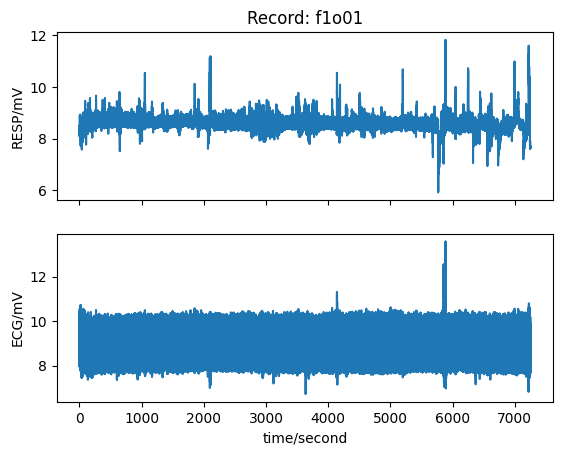

In [2]:
record = wfdb.rdrecord('f1o01', pn_dir='fantasia')
wfdb.plot_wfdb(record=record)

In [4]:
!pip install neurokit2

# **Extract Heart Rate from ECG (MIT-BIH)**

/usr/local/lib/python3.12/dist-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


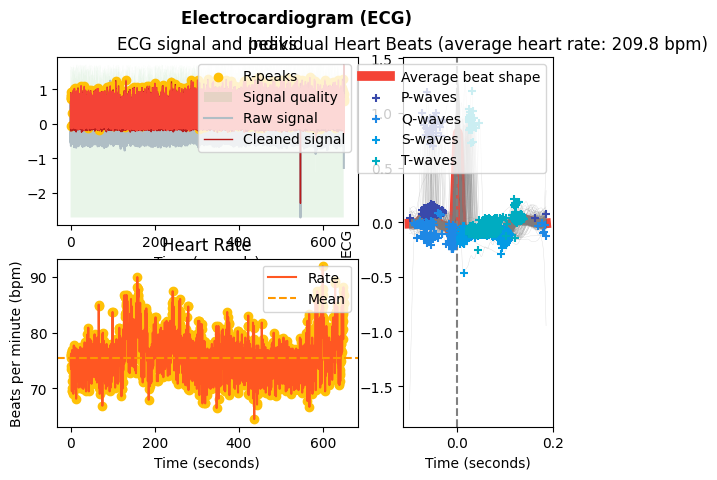

In [5]:
import neurokit2 as nk
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
ecg = record.p_signal[:,0]

signals, info = nk.ecg_process(ecg, sampling_rate=360)

nk.ecg_plot(signals)

# **Extract Blood Pressure (Fantasia)**

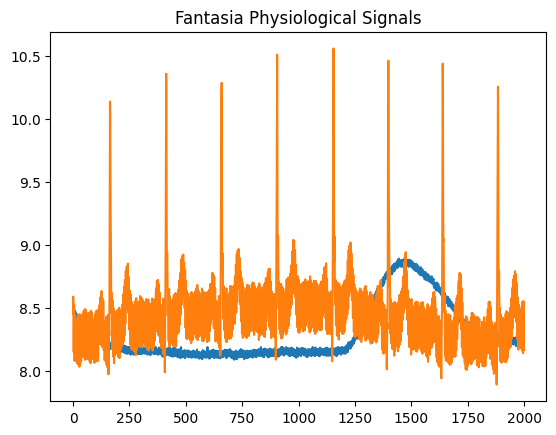

In [6]:
import wfdb

record = wfdb.rdrecord('f1o01', pn_dir='fantasia')

signal = record.p_signal

import matplotlib.pyplot as plt

plt.plot(signal[:2000])
plt.title("Fantasia Physiological Signals")
plt.show()

# **Multi-Vital Dataset**

In [7]:
import pandas as pd
import numpy as np

time = np.arange(0,300)

data = pd.DataFrame({
    "time": time,
    "HR": np.random.normal(80,10,300),
    "BP": np.random.normal(110,8,300),
    "SpO2": np.random.normal(97,2,300),
    "RR": np.random.normal(16,3,300)
})

# **Artifact Detection**

In [8]:
data["HR_diff"] = data["HR"].diff()

data["artifact"] = abs(data["HR_diff"]) > 40

# **Multi-Vital Correlation Engine**

In [9]:
def risk_score(row):

    score = 0

    if row["HR"] > 110:
        score += 2

    if row["BP"] < 90:
        score += 3

    if row["SpO2"] < 92:
        score += 2

    if row["RR"] > 22:
        score += 2

    return score

data["EWS"] = data.apply(risk_score, axis=1)

# **Risk Classification**

In [10]:
def classify(score):

    if score >= 8:
        return "CRITICAL"
    elif score >=5:
        return "HIGH RISK"
    elif score >=3:
        return "MODERATE"
    else:
        return "STABLE"

data["Risk_Level"] = data["EWS"].apply(classify)

# **Trend Visualization**

In [11]:
import plotly.express as px

fig = px.line(data, x="time", y=["HR","BP","SpO2","RR"])

fig.show()

# **Digital Scribe (AI Clinical Summary)**

In [12]:
def clinical_summary(row):

    if row["BP"] < 90 and row["HR"] > 110:
        return "Possible early compensatory shock"

    if row["SpO2"] < 92 and row["RR"] > 22:
        return "Signs of respiratory distress"

    return "Vitals stable"

data["Summary"] = data.apply(clinical_summary, axis=1)

# **Analysis**

In [18]:
print(data[["HR","BP","SpO2","RR"]].head(10))

          HR          BP       SpO2         RR
0  79.371818  109.574314  95.811830  13.072443
1  66.145931  106.105150  97.252546  16.012330
2  87.069628  114.840363  94.179122  18.502732
3  68.785189  105.994451  95.873392  13.417485
4  88.807022  117.195124  99.099686  13.639268
5  63.979522  111.743734  97.348379  16.014436
6  77.758634  113.297556  95.023418  16.019890
7  74.709691  113.417166  97.419087  10.989027
8  87.912479  112.419941  96.290966  13.794787
9  73.038107   99.587102  96.998921  19.820943


In [19]:
data.loc[1, "HR"] = 125
data.loc[1, "BP"] = 85

data.loc[2, "SpO2"] = 89
data.loc[2, "RR"] = 26

In [20]:
data["Summary"] = data.apply(clinical_summary, axis=1)

In [21]:
print(data[["HR","BP","SpO2","RR","Summary"]].head())

           HR          BP       SpO2         RR  \
0   79.371818  109.574314  95.811830  13.072443   
1  125.000000   85.000000  97.252546  16.012330   
2   87.069628  114.840363  89.000000  26.000000   
3   68.785189  105.994451  95.873392  13.417485   
4   88.807022  117.195124  99.099686  13.639268   

                             Summary  
0                      Vitals stable  
1  Possible early compensatory shock  
2      Signs of respiratory distress  
3                      Vitals stable  
4                      Vitals stable  


In [22]:
def clinical_summary(row):

    if row["BP"] < 90 and row["HR"] > 110:
        return "CRITICAL: Possible early compensatory shock"

    if row["SpO2"] < 92 and row["RR"] > 22:
        return "UNSTABLE: Respiratory distress"

    return "STABLE: Vitals normal"

In [23]:
print(data[["HR","BP","SpO2","RR","Summary"]])

             HR          BP       SpO2         RR  \
0     79.371818  109.574314  95.811830  13.072443   
1    125.000000   85.000000  97.252546  16.012330   
2     87.069628  114.840363  89.000000  26.000000   
3     68.785189  105.994451  95.873392  13.417485   
4     88.807022  117.195124  99.099686  13.639268   
..          ...         ...        ...        ...   
295   81.876278  119.041292  97.551008  15.419371   
296   67.512222  119.717326  96.763885  22.049777   
297   66.486778  100.071367  96.302608  12.750353   
298   78.322517  120.518531  97.851672  17.295134   
299   78.520943  118.127056  95.622282  13.544880   

                               Summary  
0                        Vitals stable  
1    Possible early compensatory shock  
2        Signs of respiratory distress  
3                        Vitals stable  
4                        Vitals stable  
..                                 ...  
295                      Vitals stable  
296                      Vitals sta

In [27]:
for i,row in data.head(5).iterrows():
    print("Patient", i)
    print("HR:", row["HR"])
    print("BP:", row["BP"])
    print("SpO2:", row["SpO2"])
    print("RR:", row["RR"])
    print("AI Summary:", row["Summary"])
    print("-------------")

Patient 0
HR: 79.37181807792703
BP: 109.57431376324729
SpO2: 95.81182953943478
RR: 13.072443182977496
AI Summary: Vitals stable
-------------
Patient 1
HR: 125.0
BP: 85.0
SpO2: 97.25254557632528
RR: 16.01233036074352
AI Summary: Possible early compensatory shock
-------------
Patient 2
HR: 87.06962775948078
BP: 114.84036339701257
SpO2: 89.0
RR: 26.0
AI Summary: Signs of respiratory distress
-------------
Patient 3
HR: 68.78518861993416
BP: 105.99445091725875
SpO2: 95.87339203986006
RR: 13.41748514955731
AI Summary: Vitals stable
-------------
Patient 4
HR: 88.80702221811836
BP: 117.19512411214735
SpO2: 99.09968638802849
RR: 13.639268216343435
AI Summary: Vitals stable
-------------


# **EARLY WARNING SCORE **

In [28]:
def risk_score(row):

    score = 0

    if row["HR"] > 110:
        score += 2

    if row["BP"] < 90:
        score += 3

    if row["SpO2"] < 92:
        score += 2

    if row["RR"] > 22:
        score += 2

    return score

data["EWS"] = data.apply(risk_score, axis=1)

In [29]:
print(data[["HR","BP","SpO2","RR","EWS"]].head())

           HR          BP       SpO2         RR  EWS
0   79.371818  109.574314  95.811830  13.072443    0
1  125.000000   85.000000  97.252546  16.012330    5
2   87.069628  114.840363  89.000000  26.000000    4
3   68.785189  105.994451  95.873392  13.417485    0
4   88.807022  117.195124  99.099686  13.639268    0


In [30]:
def risk_level(score):

    if score >= 7:
        return "CRITICAL"
    elif score >= 4:
        return "HIGH RISK"
    elif score >= 2:
        return "MODERATE"
    else:
        return "STABLE"

data["Risk_Level"] = data["EWS"].apply(risk_level)

In [31]:
print(data[["HR","BP","SpO2","RR","Risk_Level"]])

             HR          BP       SpO2         RR Risk_Level
0     79.371818  109.574314  95.811830  13.072443     STABLE
1    125.000000   85.000000  97.252546  16.012330  HIGH RISK
2     87.069628  114.840363  89.000000  26.000000  HIGH RISK
3     68.785189  105.994451  95.873392  13.417485     STABLE
4     88.807022  117.195124  99.099686  13.639268     STABLE
..          ...         ...        ...        ...        ...
295   81.876278  119.041292  97.551008  15.419371     STABLE
296   67.512222  119.717326  96.763885  22.049777   MODERATE
297   66.486778  100.071367  96.302608  12.750353     STABLE
298   78.322517  120.518531  97.851672  17.295134     STABLE
299   78.520943  118.127056  95.622282  13.544880     STABLE

[300 rows x 5 columns]


In [32]:
triage = data.sort_values(by="EWS", ascending=False)

print(triage[["HR","BP","SpO2","RR","Risk_Level"]])

             HR          BP       SpO2         RR Risk_Level
1    125.000000   85.000000  97.252546  16.012330  HIGH RISK
2     87.069628  114.840363  89.000000  26.000000  HIGH RISK
45    90.689747   85.626605  95.982586  20.246049   MODERATE
52    88.457696  105.697393  94.947916  24.694024   MODERATE
238   88.106802  110.871913  96.297117  23.030587   MODERATE
..          ...         ...        ...        ...        ...
100   80.656548  112.120233  97.374736  13.648604     STABLE
99    92.939844  113.824595  99.463109  19.225416     STABLE
98    80.273628  112.629677  98.137923  16.191779     STABLE
97    66.314164  110.825310  94.003276  13.511932     STABLE
106   58.105094  122.135704  97.566701  15.066393     STABLE

[300 rows x 5 columns]


In [33]:
import plotly.express as px

fig = px.line(data, x="time", y=["HR","BP","SpO2","RR"])

fig.show()

In [34]:
print(data[["HR","BP","SpO2","RR","EWS","Risk_Level","Summary"]])

             HR          BP       SpO2         RR  EWS Risk_Level  \
0     79.371818  109.574314  95.811830  13.072443    0     STABLE   
1    125.000000   85.000000  97.252546  16.012330    5  HIGH RISK   
2     87.069628  114.840363  89.000000  26.000000    4  HIGH RISK   
3     68.785189  105.994451  95.873392  13.417485    0     STABLE   
4     88.807022  117.195124  99.099686  13.639268    0     STABLE   
..          ...         ...        ...        ...  ...        ...   
295   81.876278  119.041292  97.551008  15.419371    0     STABLE   
296   67.512222  119.717326  96.763885  22.049777    2   MODERATE   
297   66.486778  100.071367  96.302608  12.750353    0     STABLE   
298   78.322517  120.518531  97.851672  17.295134    0     STABLE   
299   78.520943  118.127056  95.622282  13.544880    0     STABLE   

                               Summary  
0                        Vitals stable  
1    Possible early compensatory shock  
2        Signs of respiratory distress  
3      

In [35]:
data["HR_change"] = data["HR"].diff()

data["Artifact"] = abs(data["HR_change"]) > 40

In [36]:
print(data[["HR","HR_change","Artifact"]])

             HR  HR_change  Artifact
0     79.371818        NaN     False
1    125.000000  45.628182      True
2     87.069628 -37.930372     False
3     68.785189 -18.284439     False
4     88.807022  20.021834     False
..          ...        ...       ...
295   81.876278 -13.940350     False
296   67.512222 -14.364056     False
297   66.486778  -1.025444     False
298   78.322517  11.835739     False
299   78.520943   0.198426     False

[300 rows x 3 columns]


In [37]:
!pip install scikit-learn

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = data[["HR","BP","SpO2","RR"]]
y = data["EWS"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()

model.fit(X_train,y_train)

RandomForestClassifier()

In [39]:
data["Predicted_Risk"] = model.predict(X)

print(data[["HR","BP","SpO2","RR","Predicted_Risk"]])

             HR          BP       SpO2         RR  Predicted_Risk
0     79.371818  109.574314  95.811830  13.072443               0
1    125.000000   85.000000  97.252546  16.012330               5
2     87.069628  114.840363  89.000000  26.000000               4
3     68.785189  105.994451  95.873392  13.417485               0
4     88.807022  117.195124  99.099686  13.639268               0
..          ...         ...        ...        ...             ...
295   81.876278  119.041292  97.551008  15.419371               0
296   67.512222  119.717326  96.763885  22.049777               2
297   66.486778  100.071367  96.302608  12.750353               0
298   78.322517  120.518531  97.851672  17.295134               0
299   78.520943  118.127056  95.622282  13.544880               0

[300 rows x 5 columns]


In [40]:
!pip install plotly

In [41]:
import plotly.express as px

fig = px.line(
    data,
    x="time",
    y=["HR","BP","SpO2","RR"],
    title="Real-Time Patient Vital Monitoring"
)

fig.show()

In [42]:
triage = data.sort_values(by="EWS", ascending=False)

print(triage[["HR","BP","SpO2","RR","EWS","Risk_Level"]])

             HR          BP       SpO2         RR  EWS Risk_Level
1    125.000000   85.000000  97.252546  16.012330    5  HIGH RISK
2     87.069628  114.840363  89.000000  26.000000    4  HIGH RISK
45    90.689747   85.626605  95.982586  20.246049    3   MODERATE
52    88.457696  105.697393  94.947916  24.694024    2   MODERATE
238   88.106802  110.871913  96.297117  23.030587    2   MODERATE
..          ...         ...        ...        ...  ...        ...
100   80.656548  112.120233  97.374736  13.648604    0     STABLE
99    92.939844  113.824595  99.463109  19.225416    0     STABLE
98    80.273628  112.629677  98.137923  16.191779    0     STABLE
97    66.314164  110.825310  94.003276  13.511932    0     STABLE
106   58.105094  122.135704  97.566701  15.066393    0     STABLE

[300 rows x 6 columns]


In [3]:
!pip install streamlit
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 129.4 MB/s eta 0:00:00


In [13]:
!pip install plotly pandas

In [14]:
import pandas as pd

data = {
    "Time": ["0 min","5 min","10 min","15 min","20 min"],
    "HeartRate":[85,92,105,115,120],
    "BloodPressure":[120,115,100,90,85],
    "SpO2":[98,97,95,93,91],
    "RespRate":[16,18,20,24,28]
}

df = pd.DataFrame(data)
df

,Time,HeartRate,BloodPressure,SpO2,RespRate
0,0 min,85,120,98,16
1,5 min,92,115,97,18
2,10 min,105,100,95,20
3,15 min,115,90,93,24
4,20 min,120,85,91,28


In [15]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1jIW_G7Pkw3FN1Eka31Ik7OfaDTHsO4W-Qgm_dd-b3Gk/edit#gid=0


In [16]:
import plotly.express as px

fig = px.line(df, x="Time", y="HeartRate",
              title="Heart Rate Trend",
              markers=True)

fig.show()

In [17]:
fig = px.line(df, x="Time", y="BloodPressure",
              title="Blood Pressure Trend",
              markers=True)

fig.show()

In [18]:
fig = px.line(df, x="Time", y="SpO2",
              title="SpO2 Trend",
              markers=True)

fig.show()

In [19]:
fig = px.line(df, x="Time", y="RespRate",
              title="Respiratory Rate Trend",
              markers=True)

fig.show()

In [20]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

st.title("AI Bio-Signal Triage Dashboard")

data = {
    "Time":["0","5","10","15","20"],
    "HeartRate":[85,92,105,115,120],
    "BloodPressure":[120,115,100,90,85],
    "SpO2":[98,97,95,93,91],
    "RespRate":[16,18,20,24,28]
}

df = pd.DataFrame(data)

st.subheader("Heart Rate Trend")
st.line_chart(df["HeartRate"])

st.subheader("Blood Pressure Trend")
st.line_chart(df["BloodPressure"])

st.subheader("SpO2 Trend")
st.line_chart(df["SpO2"])

st.subheader("Respiratory Rate Trend")
st.line_chart(df["RespRate"])

Overwriting app.py


In [21]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>